In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel(r'C:\AQI\data\AirQualityUCI.xlsx')
df.shape

(9357, 15)

In [17]:
# cheking info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[us]
 1   Time           8967 non-null   datetime64[us]
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetime64[us](2), float64(12

In [18]:
# drop unwanted columns
df.drop(columns=['Date','Time'],inplace=True)

In [19]:
#cheking duplicates
df.duplicated().sum()


np.int64(31)

In [20]:
# chekng null
df.isnull().sum()

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [21]:
# checking descriptive stats
numerical_data=df.select_dtypes(include='number')

from collections import OrderedDict

stats=[]

for i in numerical_data.columns:
    numerical_stats=OrderedDict({
        'Feature':i,
        'Count':numerical_data[i].count(),
        'Mean':numerical_data[i].mean(),
        'Median':numerical_data[i].median(),
        'Max':numerical_data[i].max(),
        'Min':numerical_data[i].min(),
        'Q1':numerical_data[i].quantile(0.25),
        'Q3':numerical_data[i].quantile(0.75),
        'IQR':numerical_data[i].quantile(0.75)-numerical_data[i].quantile(0.25),
        'Standard Deviation':numerical_data[i].std(),
        'Skewness':numerical_data[i].skew(),
        'Kurtosis':numerical_data[i].kurt()
        
    })
    stats.append(numerical_stats)
report=pd.DataFrame(stats)
report


,Feature,Count,Mean,Median,Max,Min,Q1,Q3,IQR,Standard Deviation,Skewness,Kurtosis
0,CO(GT),9357,-34.207524,1.500000,11.900000,-200.0,0.600000,2.600000,2.000000,77.657170,-1.666180,0.778306
1,PT08.S1(CO),9357,1048.869652,1052.500000,2039.750000,-200.0,921.000000,1221.250000,300.250000,329.817015,-1.721126,5.835512
2,NMHC(GT),9357,-159.090093,-200.000000,1189.000000,-200.0,-200.000000,-200.000000,0.000000,139.789093,4.075784,18.863824
3,C6H6(GT),9357,1.865576,7.886653,63.741476,-200.0,4.004958,13.636091,9.631133,41.380154,-4.508775,19.188714
4,PT08.S2(NMHC),9357,894.475963,894.500000,2214.000000,-200.0,711.000000,1104.750000,393.750000,342.315902,-0.793153,2.369425
5,NOx(GT),9357,168.604200,141.000000,1479.000000,-200.0,50.000000,284.200000,234.200000,257.424561,0.825255,1.505566
6,PT08.S3(NOx),9357,794.872333,794.250000,2682.750000,-200.0,637.000000,960.250000,323.250000,321.977031,-0.384464,3.104215
7,NO2(GT),9357,58.135898,96.000000,339.700000,-200.0,53.000000,133.000000,80.000000,126.931428,-1.225789,0.275717
8,PT08.S4(NO2),9357,1391.363266,1445.500000,2775.000000,-200.0,1184.750000,1662.000000,477.250000,467.192382,-1.243944,3.266388
9,PT08.S5(O3),9357,974.951534,942.000000,2522.750000,-200.0,699.750000,1255.250000,555.500000,456.922728,-0.034500,0.637957


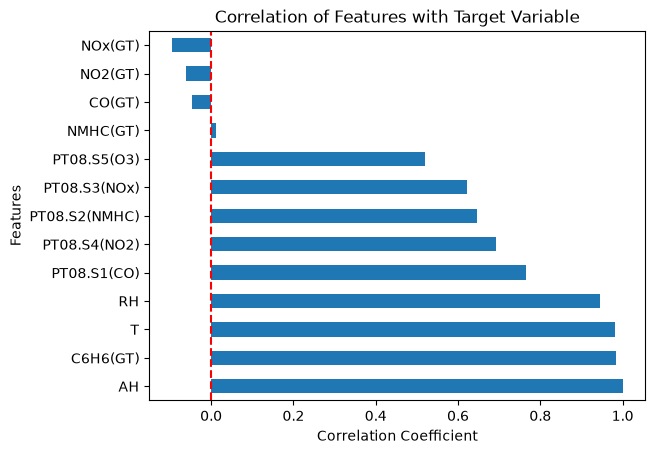

In [23]:
# Cheking cor-relation with target columns 

df.corr()['AH'].sort_values(ascending=False).plot(kind='barh',grid=False)
plt.axvline(x=0,color='red',linestyle='--')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.title('Correlation of Features with Target Variable')
plt.show()


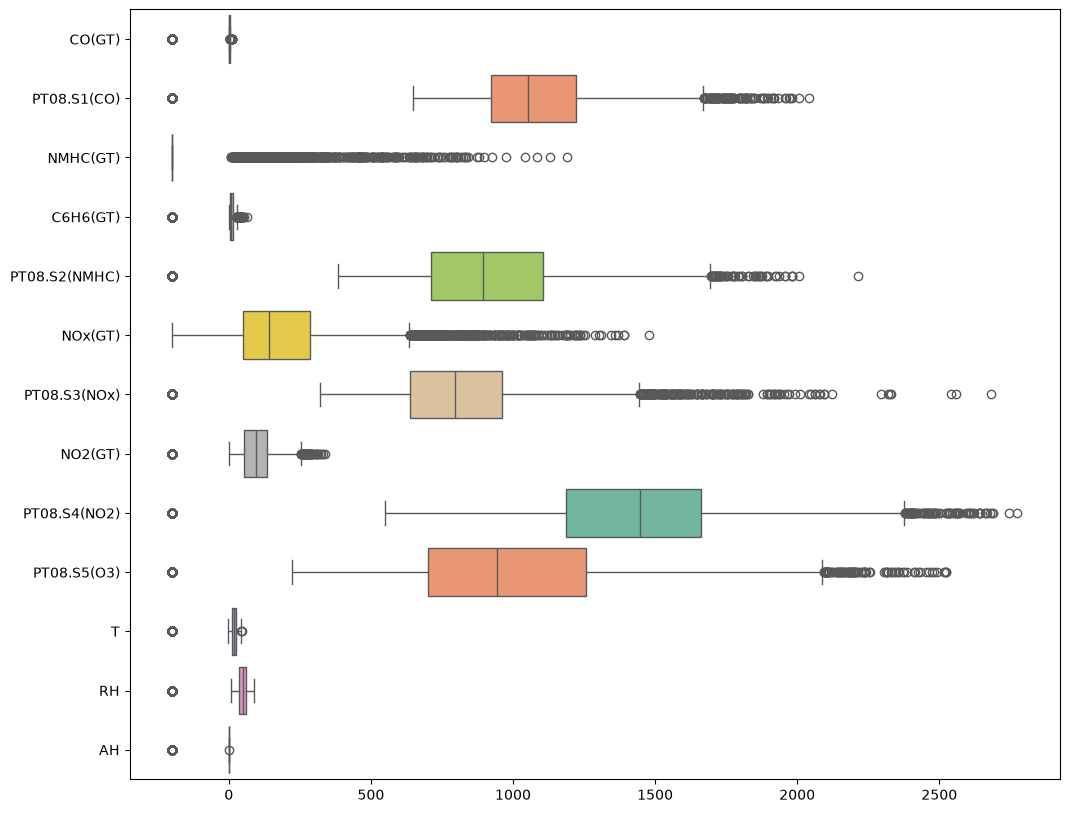

In [24]:
# checking outliers using boxplot

plt.figure(figsize=(12,10))
sns.boxplot(data=df,orient='h',palette='Set2')
plt.grid(False)
plt.show()

In [25]:
# data split and scaling
'''
X = independent columns 
y = dependent columns

X in capital means more than one column
y in small means only one column
'''

from sklearn.model_selection import train_test_split

X=df.drop(columns=['AH'])
y=df['AH']

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,
                                               random_state=1)

In [27]:

from sklearn.preprocessing import MinMaxScaler

sc=MinMaxScaler()

X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [29]:
# checking different models ans their accuracy
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

models = {
    'Linear Regression':LinearRegression(),
    'Ridge':Ridge(),
    'Lasso':Lasso(),
    'Elastic Net':ElasticNet(),
    'Decision Tree Regressor':DecisionTreeRegressor(),
    'Random Forest Regressor':RandomForestRegressor()
}

for model_name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    r2_score_test=model.score(X_test,y_test)
    r2_score_train=model.score(X_train,y_train)
    

    
    print(f'{model_name} Training R2 score is {r2_score_train}')
    print(f'{model_name} Test R2 score is {r2_score_test}')
    print(f'{model_name} MSE is {mean_squared_error(y_test,y_pred)}')
    print(f'{model_name} MAE is {mean_absolute_error(y_test,y_pred)}')
    print()
    print()
   
   


Linear Regression Training R2 score is 0.9993700225443622
Linear Regression Test R2 score is 0.9992291189613114
Linear Regression MSE is 1.1523718958626177
Linear Regression MAE is 0.7540739049990322


Ridge Training R2 score is 0.9989069781633949
Ridge Test R2 score is 0.9988347671164365
Ridge MSE is 1.741879174298886
Ridge MAE is 1.0134593405565775


Lasso Training R2 score is 0.9664741304708289
Lasso Test R2 score is 0.9665910722692718
Lasso MSE is 49.942218650613356
Lasso MAE is 3.9079048088528947


Elastic Net Training R2 score is 0.3344941032201487
Elastic Net Test R2 score is 0.33481538656759147
Elastic Net MSE is 994.368800903176
Elastic Net MAE is 12.235738959514293


Decision Tree Regressor Training R2 score is 1.0
Decision Tree Regressor Test R2 score is 0.9999990847987983
Decision Tree Regressor MSE is 0.0013681127061545353
Decision Tree Regressor MAE is 0.02320789811604791


Random Forest Regressor Training R2 score is 0.9999999782178305
Random Forest Regressor Test R2 sco